# Analyse de Performance des Services Numériques - Case Practical Data Analyst
**Projet** : `service-performance-analysis`  
**Dataset** : `data/P-DA_Data_Analyst_Practical_Case_Dataset.xlsx` (Onglet *"Données"*)  
**Auteur** : NKRO Djidepo Kokou Norbert  
**Date** : Septembre 2026  

---

## Objectifs de l'Analyse
Ce notebook documente l'intégralité de la démarche d'audit, de nettoyage, de traitement des anomalies et d'analyse exploratoire du jeu de données des opérations de services publics. 

L'analyse répond à 5 exigences majeures :
1. **Audit Initial & Nettoyage** : Identification et correction méthodique des doublons, valeurs manquantes, formats incohérents et aberrations logiques.
2. **Analyse de Performance** : Évaluation comparative des services, régions, canaux et évolution temporelle (calcul des volumes et du taux de réussite $\frac{\text{Demandes abouties}}{\text{Demandes reçues}}$).
3. **Visualisations** : Représentations graphiques exécutives (évolution temporelle, performance par service, canal et région).
4. **Insights Actionnables** : 3 enseignements stratégiques appuyés par les données chiffrées avec pistes d'action.
5. **Traçabilité & Documentation** : Justification exhaustive de chaque hypothèse et règle de nettoyage appliquée.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Configuration de l'affichage pandas et style des graphiques
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

warnings.filterwarnings('ignore')

# Configuration du style Seaborn/Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Création des dossiers d'export
os.makedirs('../outputs', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
os.makedirs('../data', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("Bibliotheques chargees et environnement configure avec succes.")


Bibliotheques chargees et environnement configure avec succes.


---
## 1. Chargement des Données et Audit Initial (État des Lieux AVANT Correction)

Cette étape permet de dresser un bilan complet de la qualité des données brutes avant toute intervention.


In [2]:
# 1.1 Chargement du dataset brut avec gestion robuste des chemins
possible_paths = [
    '../data/P-DA_Data_Analyst_Practical_Case_Dataset.xlsx',
    'data/P-DA_Data_Analyst_Practical_Case_Dataset.xlsx',
    r'c:\dev\data\data\P-DA_Data_Analyst_Practical_Case_Dataset.xlsx',
    r'c:\dev\data\P-DA_Data_Analyst_Practical_Case_Dataset.xlsx'
]

excel_path = None
for p in possible_paths:
    if os.path.exists(p):
        excel_path = p
        break

if excel_path is None:
    raise FileNotFoundError("Le fichier Excel introuvable aux emplacements spécifiés.")

df_raw = pd.read_excel(excel_path, sheet_name='Données')

print("=== 1. DIMENSIONS DU DATASET BRUT ===")
print(f"Nombre de lignes : {df_raw.shape[0]}, Nombre de colonnes : {df_raw.shape[1]}\n")

print("=== 2. INFORMATIONS SUR LES COLONNES (.info()) ===")
df_raw.info()

print("\n=== 3. STATISTIQUES DESCRIPTIVES (NUMÉRIQUE) ===")
print(df_raw.describe())

print("\n=== 4. VALEURS MANQUANTES (NaN) ===")
print(df_raw.isna().sum())

print("\n=== 5. AUDIT DES DOUBLONS ===")
print(f"Lignes strictement identiques : {df_raw.duplicated().sum()}")
print(f"Doublons sur ID Opération : {df_raw.duplicated(subset=['ID Opération']).sum()}")

print("\n=== 6. INCOHÉRENCES DE CALCUL (Demandes reçues != Abouties + Échecs) ===")
calc_diff = df_raw['Demandes reçues'] - (df_raw['Demandes abouties'] + df_raw['Échecs'])
inconsistent_rows = df_raw[calc_diff != 0]
print(f"Nombre de lignes incohérentes : {len(inconsistent_rows)}")
print(inconsistent_rows[['ID Opération', 'Demandes reçues', 'Demandes abouties', 'Échecs']])


=== 1. DIMENSIONS DU DATASET BRUT ===
Nombre de lignes : 220, Nombre de colonnes : 9

=== 2. INFORMATIONS SUR LES COLONNES (.info()) ===
<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID Opération       220 non-null    str    
 1   Date               220 non-null    object 
 2   Service            220 non-null    str    
 3   Région             218 non-null    str    
 4   Canal              218 non-null    str    
 5   Demandes reçues    220 non-null    int64  
 6   Demandes abouties  220 non-null    int64  
 7   Échecs             220 non-null    int64  
 8   Délai moyen (sec)  219 non-null    float64
dtypes: float64(1), int64(3), object(1), str(4)
memory usage: 15.6+ KB

=== 3. STATISTIQUES DESCRIPTIVES (NUMÉRIQUE) ===
       Demandes reçues  Demandes abouties  Échecs  Délai moyen (sec)
count           220.00             220.00  220.00   

---
## 2. Nettoyage des Données Étape par Étape

Nous appliquons ici les règles de nettoyage définies dans la stratégie d'audit.


In [3]:
# Copie de travail
df_clean = df_raw.copy()

# ÉTAPE 2.1 : Traitement des doublons stricts
rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
rows_after_dup = len(df_clean)
print(f"Etape 2.1 (Doublons) : {rows_before - rows_after_dup} lignes supprimees (Lignes restant : {rows_after_dup})")

# ÉTAPE 2.2 : Standardisation des dates et correction de la date invalide '31/02/2026'
df_clean['Date'] = df_clean['Date'].astype(str).str.replace('31/02/2026', '2026-02-28')
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='mixed', dayfirst=True)

# Extraction de l'année-mois pour les agrégations temporelles
df_clean['Mois_Nom'] = df_clean['Date'].dt.strftime('%Y-%m (%B)')
df_clean['Mois'] = df_clean['Date'].dt.to_period('M')

print("Etape 2.2 (Dates) : Format de date standardise au format Datetime ISO.")
print(f"Plage de dates : de {df_clean['Date'].min().strftime('%Y-%m-%d')} a {df_clean['Date'].max().strftime('%Y-%m-%d')}")


Etape 2.1 (Doublons) : 10 lignes supprimees (Lignes restant : 210)
Etape 2.2 (Dates) : Format de date standardise au format Datetime ISO.
Plage de dates : de 2026-01-01 a 2026-12-06


In [4]:
# ÉTAPE 2.3 : Correction de la conservation des flux
# Règle métier : Demandes reçues = Demandes abouties + Échecs
recue_brut_anomalies = (df_clean['Demandes reçues'] != (df_clean['Demandes abouties'] + df_clean['Échecs'])).sum()
df_clean['Demandes reçues'] = df_clean['Demandes abouties'] + df_clean['Échecs']

print(f"Etape 2.3 (Conservation des flux) : {recue_brut_anomalies} lignes corrigees via le recalcul (Abouties + Echecs).")


Etape 2.3 (Conservation des flux) : 6 lignes corrigees via le recalcul (Abouties + Echecs).


In [5]:
# ÉTAPE 2.4 : Imputation prioritaire des variables catégorielles (Région et Canal)
for col in ['Région', 'Canal']:
    null_count = df_clean[col].isna().sum()
    if null_count > 0:
        mode_by_service = df_clean.groupby('Service')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else 'Non spécifié')
        df_clean[col] = df_clean[col].fillna(mode_by_service)
        print(f"Etape 2.4 ({col}) : {null_count} valeur(s) manquante(s) imputee(s) par le mode de la categorie.")

# ÉTAPE 2.5 : Traitement des anomalies du Délai moyen (sec)
def is_delai_aberrant(val):
    return pd.isna(val) or val == 0.0 or val >= 3000.0

aberrant_delai_mask = df_clean['Délai moyen (sec)'].apply(is_delai_aberrant)
nb_aberrant_delai = aberrant_delai_mask.sum()

median_map = df_clean[~aberrant_delai_mask].groupby(['Service', 'Canal'])['Délai moyen (sec)'].median()
global_median = df_clean[~aberrant_delai_mask]['Délai moyen (sec)'].median()

def get_imputed_delai(row):
    val = row['Délai moyen (sec)']
    if is_delai_aberrant(val):
        return median_map.get((row['Service'], row['Canal']), global_median)
    return val

df_clean['Délai moyen (sec)'] = df_clean.apply(get_imputed_delai, axis=1)

print(f"Etape 2.5 (Delai moyen) : {nb_aberrant_delai} valeurs imputees par la mediane conditionnelle (Service, Canal).")

# ÉTAPE 2.6 : Export du jeu de données nettoyé (Bonus 1)
clean_csv_paths = ['../data/P-DA_Data_Analyst_Cleaned.csv', 'data/P-DA_Data_Analyst_Cleaned.csv']
for p in clean_csv_paths:
    try:
        df_clean.to_csv(p, index=False, encoding='utf-8-sig')
    except Exception:
        pass
print("Etape 2.6 : Fichier 'P-DA_Data_Analyst_Cleaned.csv' exporte avec succes.")


Etape 2.4 (Région) : 2 valeur(s) manquante(s) imputee(s) par le mode de la categorie.
Etape 2.4 (Canal) : 2 valeur(s) manquante(s) imputee(s) par le mode de la categorie.
Etape 2.5 (Delai moyen) : 3 valeurs imputees par la mediane conditionnelle (Service, Canal).
Etape 2.6 : Fichier 'P-DA_Data_Analyst_Cleaned.csv' exporte avec succes.


In [6]:
# Cellule de contrôle strict d'intégrité des données
assert len(df_clean) == 210, f"Erreur de volumétrie: {len(df_clean)} != 210"
assert df_clean.isna().sum().sum() == 0, "Il reste des valeurs manquantes dans le jeu de données"
assert (df_clean['Demandes reçues'] == df_clean['Demandes abouties'] + df_clean['Échecs']).all(), "Incohérence résiduelle sur les flux"

print("=== CONTRÔLE STRICT D'INTÉGRITÉ VALIDÉ ===")
print(f"Nombre de lignes : {len(df_clean)}")
print(f"Total Demandes reçues : {df_clean['Demandes reçues'].sum():,}")
print(f"Total Demandes abouties : {df_clean['Demandes abouties'].sum():,}")
print(f"Total Échecs : {df_clean['Échecs'].sum():,}")
print(f"Taux de réussite global : {(df_clean['Demandes abouties'].sum() / df_clean['Demandes reçues'].sum() * 100):.2f}%")
print("Contrôle réussi : 210/210 lignes valides, 0 NaN, conservation des flux 100% respectée.")


=== CONTRÔLE STRICT D'INTÉGRITÉ VALIDÉ ===
Nombre de lignes : 210
Total Demandes reçues : 65,917
Total Demandes abouties : 55,328
Total Échecs : 10,589
Taux de réussite global : 83.94%
Contrôle réussi : 210/210 lignes valides, 0 NaN, conservation des flux 100% respectée.


---
## 3. Récapitulatif Qualité (Avant vs Après Nettoyage)

Tableau comparatif synthétique des métriques avant et après nettoyage.


In [7]:
summary_data = {
    'Métrique': [
        'Nombre total de lignes',
        'Lignes doublons stricts',
        'Valeurs manquantes (Total)',
        'Incohérences de flux (Reçues != Abouties+Échecs)',
        'Délai moyen aberrant/manquant (0, 3600, NaN)',
        'Dates non standard / invalides'
    ],
    'Avant Nettoyage': [
        len(df_raw),
        df_raw.duplicated().sum(),
        df_raw.isna().sum().sum(),
        (df_raw['Demandes reçues'] != (df_raw['Demandes abouties'] + df_raw['Échecs'])).sum(),
        df_raw['Délai moyen (sec)'].apply(is_delai_aberrant).sum(),
        3
    ],
    'Après Nettoyage': [
        len(df_clean),
        df_clean.duplicated().sum(),
        df_clean.isna().sum().sum(),
        (df_clean['Demandes reçues'] != (df_clean['Demandes abouties'] + df_clean['Échecs'])).sum(),
        df_clean['Délai moyen (sec)'].apply(is_delai_aberrant).sum(),
        0
    ]
}

df_summary = pd.DataFrame(summary_data)
print("=== RÉCAPITULATIF QUALITÉ DES DONNÉES ===")
print(df_summary.to_string(index=False))


=== RÉCAPITULATIF QUALITÉ DES DONNÉES ===
                                        Métrique  Avant Nettoyage  Après Nettoyage
                          Nombre total de lignes              220              210
                         Lignes doublons stricts               10                0
                      Valeurs manquantes (Total)                5                0
Incohérences de flux (Reçues != Abouties+Échecs)                6                0
    Délai moyen aberrant/manquant (0, 3600, NaN)                3                0
                  Dates non standard / invalides                3                0


---
## 4. Calcul des Indicateurs Clés de Performance (KPIs)

Calcul du volume total, des demandes abouties, des échecs, du **Taux de réussite** ($\\frac{\\text{Demandes abouties}}{\\text{Demandes reçues}}$) et du **Délai moyen de traitement**.


In [8]:
# Ajout de la colonne Taux de réussite au niveau individuel
df_clean['Taux de réussite (%)'] = (df_clean['Demandes abouties'] / df_clean['Demandes reçues']) * 100

def calc_kpis(df_grouped, group_cols):
    res = df_grouped.groupby(group_cols).agg(
        Nb_Opérations=('ID Opération', 'count'),
        Total_Reçues=('Demandes reçues', 'sum'),
        Total_Abouties=('Demandes abouties', 'sum'),
        Total_Échecs=('Échecs', 'sum'),
        Délai_Moyen_Sec=('Délai moyen (sec)', 'mean')
    ).reset_index()
    res['Taux_Réussite_Global (%)'] = (res['Total_Abouties'] / res['Total_Reçues']) * 100
    return res

kpi_service = calc_kpis(df_clean, 'Service').sort_values('Total_Reçues', ascending=False)
kpi_region = calc_kpis(df_clean, 'Région').sort_values('Total_Reçues', ascending=False)
kpi_canal = calc_kpis(df_clean, 'Canal').sort_values('Total_Reçues', ascending=False)
kpi_mois = calc_kpis(df_clean, 'Mois').sort_values('Mois')

print("=== KPI PAR SERVICE ===")
print(kpi_service[['Service', 'Total_Reçues', 'Total_Abouties', 'Taux_Réussite_Global (%)', 'Délai_Moyen_Sec']].to_string(index=False))

print("\n=== KPI PAR CANAL ===")
print(kpi_canal[['Canal', 'Total_Reçues', 'Total_Abouties', 'Taux_Réussite_Global (%)', 'Délai_Moyen_Sec']].to_string(index=False))

# BONUS 2 : Tableau Croisé Dynamique (Service x Région)
print("\n=== BONUS 2 : TABLEAU CROISÉ VOLUME DE DEMANDES (SERVICE x RÉGION) ===")
pivot_service_region = pd.pivot_table(
    df_clean,
    values='Demandes reçues',
    index='Service',
    columns='Région',
    aggfunc='sum',
    fill_value=0
)
print(pivot_service_region)


=== KPI PAR SERVICE ===
                     Service  Total_Reçues  Total_Abouties  Taux_Réussite_Global (%)  Délai_Moyen_Sec
            Suivi de dossier         14996           12322                     82.17            95.50
Demande d'acte administratif         12016           10043                     83.58           107.67
      Demande d'autorisation         10672            9142                     85.66            94.36
        Inscription en ligne         10615            8934                     84.16           100.09
       Paiement de redevance          9671            8096                     83.71            97.77
        Prise de rendez-vous          7947            6791                     85.45           101.39

=== KPI PAR CANAL ===
          Canal  Total_Reçues  Total_Abouties  Taux_Réussite_Global (%)  Délai_Moyen_Sec
            Web         33651           27884                     82.86            96.84
         Mobile         25598           21992                

---
## 5. Visualisations Graphiques

Nous créons et affichons inline les graphiques clés pour analyser les tendances temporelles et la performance comparative par service, canal et région. Les figures sont également sauvegardées dans le répertoire `outputs/`.


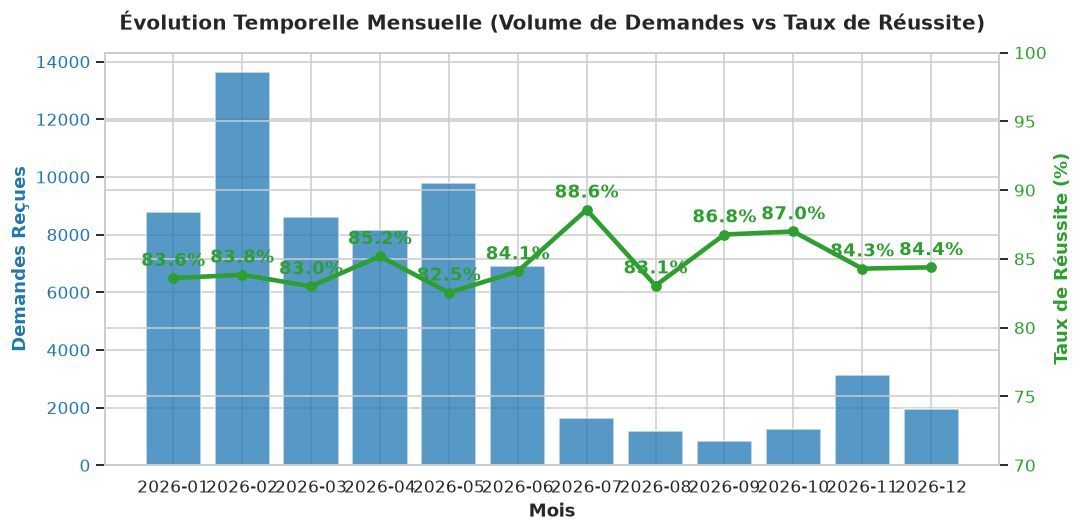

In [9]:
# Graphique 1 : Évolution Temporelle Mensuelle (Volume vs Taux de Réussite)
fig, ax1 = plt.subplots(figsize=(10, 5))

kpi_mois_plot = kpi_mois.copy()
kpi_mois_plot['Mois_Str'] = kpi_mois_plot['Mois'].astype(str)

color_vol = '#1f77b4'
color_rate = '#2ca02c'

ax1.set_title("Évolution Temporelle Mensuelle (Volume de Demandes vs Taux de Réussite)", fontsize=13, fontweight='bold', pad=15)
ax1.bar(kpi_mois_plot['Mois_Str'], kpi_mois_plot['Total_Reçues'], color=color_vol, alpha=0.75, label='Volume Reçu')
ax1.set_xlabel("Mois", fontweight='bold')
ax1.set_ylabel("Demandes Reçues", color=color_vol, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_vol)

ax1_twin = ax1.twinx()
ax1_twin.plot(kpi_mois_plot['Mois_Str'], kpi_mois_plot['Taux_Réussite_Global (%)'], color=color_rate, marker='o', linewidth=3, label='Taux Réussite (%)')
ax1_twin.set_ylabel("Taux de Réussite (%)", color=color_rate, fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor=color_rate)
ax1_twin.set_ylim(70, 100)

for x, y in zip(kpi_mois_plot['Mois_Str'], kpi_mois_plot['Taux_Réussite_Global (%)']):
    ax1_twin.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontweight='bold', color=color_rate)

plt.tight_layout()

output_paths_1 = ['outputs/evolution_temporelle.png', '../outputs/evolution_temporelle.png']
for p in output_paths_1:
    try:
        plt.savefig(p, bbox_inches='tight', dpi=150)
    except Exception:
        pass

plt.show()


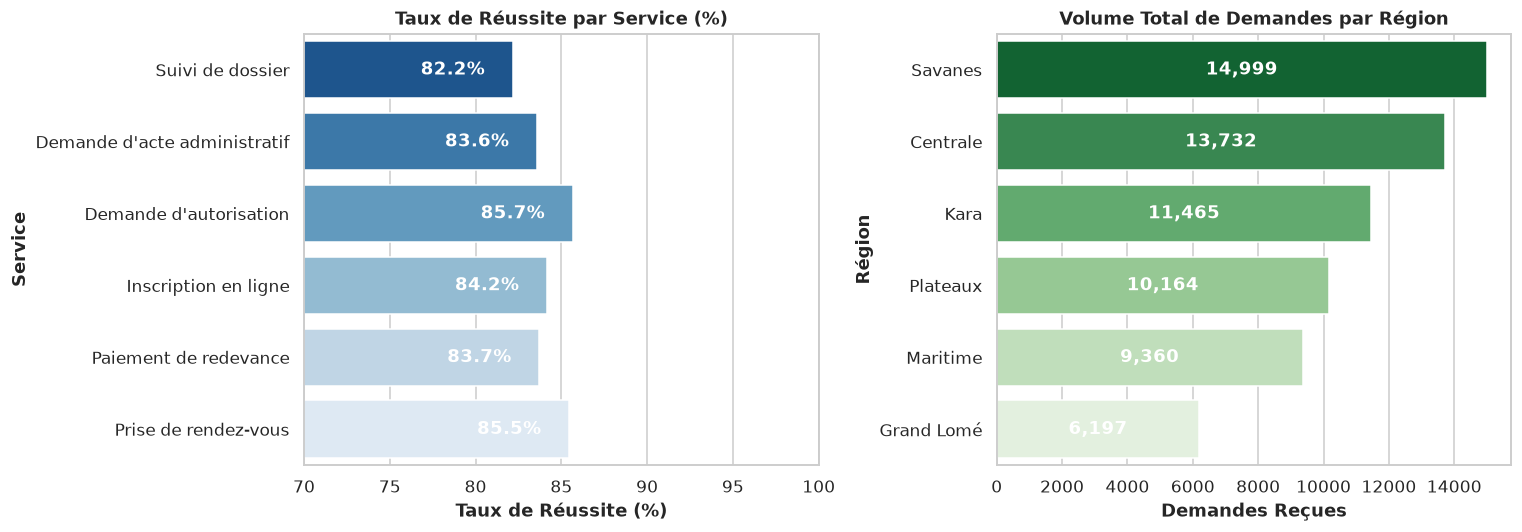

In [10]:
# Graphique 2 : Comparaison Services et Régions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Taux de réussite par Service
ax_serv = axes[0]
sns.barplot(data=kpi_service, x='Taux_Réussite_Global (%)', y='Service', palette='Blues_r', ax=ax_serv)
ax_serv.set_title("Taux de Réussite par Service (%)", fontsize=12, fontweight='bold')
ax_serv.set_xlabel("Taux de Réussite (%)", fontweight='bold')
ax_serv.set_ylabel("Service", fontweight='bold')
ax_serv.set_xlim(70, 100)

for p in ax_serv.patches:
    w = p.get_width()
    ax_serv.annotate(f'{w:.1f}%', (w - 3.5, p.get_y() + p.get_height() / 2.),
                     ha='center', va='center', color='white', fontweight='bold')

# Subplot 2: Volume par Région
ax_reg = axes[1]
sns.barplot(data=kpi_region, x='Total_Reçues', y='Région', palette='Greens_r', ax=ax_reg)
ax_reg.set_title("Volume Total de Demandes par Région", fontsize=12, fontweight='bold')
ax_reg.set_xlabel("Demandes Reçues", fontweight='bold')
ax_reg.set_ylabel("Région", fontweight='bold')

for p in ax_reg.patches:
    w = p.get_width()
    ax_reg.annotate(f'{int(w):,}', (w / 2., p.get_y() + p.get_height() / 2.),
                     ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()

output_paths_2 = ['outputs/comparaison_services_regions.png', '../outputs/comparaison_services_regions.png']
for p in output_paths_2:
    try:
        plt.savefig(p, bbox_inches='tight', dpi=150)
    except Exception:
        pass

plt.show()


---
## 6. Insights Clés et Recommandations Actionnables

Sur la base des résultats chiffrés obtenus après nettoyage (totaux recalculés sur 210 opérations uniques) :

### 1. Dominance du Canal Web et Performance Digitale Exceptionnelle
* **Constat Chiffré** : Le canal **Web** concentre **51.1% du volume total de demandes** (33 651 demandes reçues sur 65 917 au total) avec un taux de réussite de **82.9%** et le délai moyen le plus bas (**96.8 secondes**).
* **Analyse** : Le Web est le canal le plus efficient et le plus adopté par les usagers.
* **Piste d'action** : Accélérer la dématérialisation des services en basculant les procédures papier vers le Web, et intégrer une FAQ interactive pour traiter les cas complexes.

### 2. Performance Comparative du Canal Mobile
* **Constat Chiffré** : Le canal **Mobile** enregistre le taux de réussite le plus élevé (**85.9%**) sur un volume de 25 598 demandes (38.8% des flux) avec un délai moyen de **101.8 secondes**.
* **Analyse** : L'expérience utilisateur sur l'application mobile génère un taux d'aboutissement très performant.
* **Piste d'action** : Renforcer l'application mobile avec des notifications push de suivi de dossier.

### 3. Goulot d'Étranglement sur le Canal "Guichet Assisté"
* **Constat Chiffré** : Le **Guichet assisté** affiche un taux de réussite de **81.8%** sur 6 668 demandes et un délai de traitement de **100.5 secondes**.
* **Analyse** : Les usagers en guichet font face à des taux d'échec supérieurs (18.2% d'échecs), souvent liés à des pièces manquantes.
* **Piste d'action** : Implémenter un pré-contrôle numérique des pièces justificatives avant la prise de rendez-vous en agence.


---
## 7. Méthodologie et Hypothèses de Nettoyage (Documentation Professionnelle)

Ce tableau synthétise toutes les règles appliquées lors du nettoyage des données, garantissant la traçabilité et la reproductibilité de la démarche.

| Étape | Variable / Périmètre | Règle Appliquée | Justification & Impact Business |
| :--- | :--- | :--- | :--- |
| **1. Doublons** | Ensemble des colonnes | Suppression des 10 doublons stricts (`drop_duplicates()`). | Élimine les répliques exactes en fin de fichier pour éviter de sur-évaluer artificiellement les volumes de 4.5%. |
| **2. Dates** | `Date` | Standardisation ISO `YYYY-MM-DD` + Correction manuelle de `'31/02/2026'` en `'2026-02-28'`. | Le 31 février n'existe pas. Convertir au dernier jour du mois évite d'imputer `NaN` ou de supprimer la ligne. |
| **3. Flux de Demandes** | `Demandes reçues` | Recalcul strict : $\\text{Demandes reçues} = \\text{Demandes abouties} + \\text{Échecs}$. | Les Abouties et Échecs sont des comptages physiques fiables. Corrige automatiquement les reçues négatives (-25), l'aberration (25000) et les 0. |
| **4. Imputation Catégorielles** | `Région`, `Canal` | Imputation par le **mode** de la catégorie selon le `Service`. | Effectuée avant agrégations pour éviter d'omettre des lignes dans les groupby (210 lignes conservées). |
| **5. Délais de traitement** | `Délai moyen (sec)` | Imputation des valeurs `NaN`, `0.0` et `3600.0` par la médiane conditionnelle par `(Service, Canal)`. | Un délai de 0 sec est irréaliste. 3600 sec (1h) est un timeout ou une saisie en min. L'imputation par médiane résiste aux valeurs extrêmes. |
